In [4]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


Loading training data...
Loading validation data...
Train: 1512 images | 1512 HSV | 1512 texture | 1512 labels
Val  : 92 images | 92 HSV | 92 texture | 92 labels
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 STAGE 1: Training with frozen MobileNet 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.2340 - loss: 2.8116 - val_accuracy: 0.4000 - val_loss: 1.2901
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2899 - loss: 1.4753 - val_accuracy: 0.4375 - val_loss: 1.2440
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3318 - loss: 1.3196 - val_accuracy: 0.4125 - val_loss: 1.1991
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3451 - loss: 1.2786 - val_accuracy: 0.4250 - val_loss: 1.1792
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3996 - loss: 1.2300 - val_accuracy: 0.4500 - val_loss: 1.1643
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4262 - loss: 1.1974 - val_accuracy: 0.

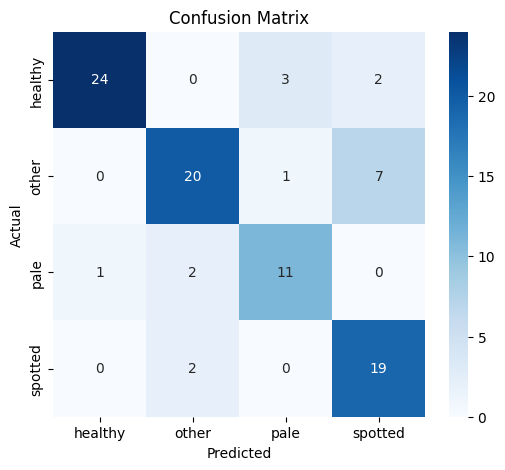

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
              precision    recall  f1-score   support

     healthy       0.70      0.90      0.79        29
       other       0.70      0.25      0.37        28
        pale       0.50      0.64      0.56        14
     spotted       0.48      0.62      0.54        21

    accuracy                           0.60        92
   macro avg       0.60      0.60      0.57        92
weighted avg       0.62      0.60      0.57        92


--- STAGE 2 Results ---



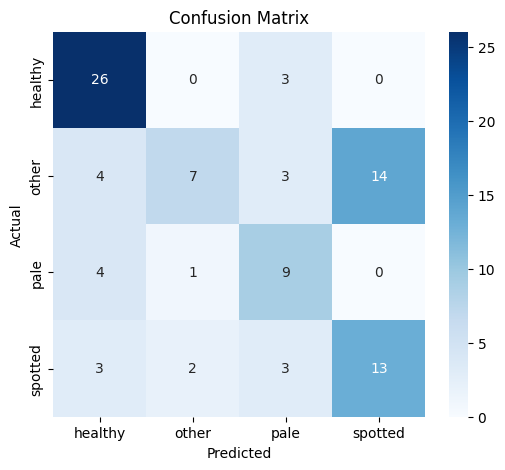

['/content/drive/MyDrive/texture_scaler.pkl']

In [2]:
#final model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from skimage.feature import graycomatrix, graycoprops
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Directories
train_dir = "/content/drive/MyDrive/comb_dataset_nopad/train"
val_dir   = "/content/drive/MyDrive/comb_dataset_nopad/val"

# Helpers
def apply_mask(img_rgb):
    hsv    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask   = cv2.inRange(hsv, np.array([0, 1, 1]), np.array([179, 255, 255]))
    masked = img_rgb.copy()
    masked[mask == 0] = 0
    return masked, mask

def extract_hsv_features(img_rgb, mask):

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H, S, V = cv2.split(hsv)

    mean_H = cv2.meanStdDev(H, mask)[0][0][0]
    std_H  = cv2.meanStdDev(H, mask)[1][0][0]
    mean_S = cv2.meanStdDev(S, mask)[0][0][0]
    std_S  = cv2.meanStdDev(S, mask)[1][0][0]
    mean_V = cv2.meanStdDev(V, mask)[0][0][0]
    std_V  = cv2.meanStdDev(V, mask)[1][0][0]

    return [mean_H, std_H, mean_S, std_S, mean_V, std_V]

def extract_texture_features(img_rgb):

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    contrast    = graycoprops(glcm, 'contrast').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy      = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()

    return [contrast, homogeneity, energy, correlation]

def load_data(directory):

    images, hsv_features, texture_features, labels = [], [], [], []

    for class_name in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue

        for filename in sorted(os.listdir(class_dir)):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img = cv2.imread(os.path.join(class_dir, filename))

            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            masked_img, mask = apply_mask(img_rgb)
            if np.count_nonzero(mask) == 0:
                continue

            # Extract HSV from original (pre-resize) masked image
            hsv = extract_hsv_features(img_rgb, mask)

            # Prepare image: masked → RGB → resized

            img_rgb_resized = cv2.resize(masked_img, (224, 224))

            # Extract texture from resized RGB image
            texture = extract_texture_features(img_rgb_resized)

            images.append(img_rgb_resized)
            hsv_features.append(hsv)
            texture_features.append(texture)
            labels.append(class_name)

    return (np.array(images), np.array(hsv_features),
            np.array(texture_features), np.array(labels))


#  Load data
print("Loading training data...")
image_train, hsv_train, texture_train, label_train = load_data(train_dir)

print("Loading validation data...")
image_val, hsv_val, texture_val, label_val = load_data(val_dir)

#  Normalize features (fit only on train)
hsv_scaler     = StandardScaler()
texture_scaler = StandardScaler()

hsv_train     = hsv_scaler.fit_transform(hsv_train)
hsv_val       = hsv_scaler.transform(hsv_val)
texture_train = texture_scaler.fit_transform(texture_train)
texture_val   = texture_scaler.transform(texture_val)

#  Label encoding
le      = LabelEncoder()
y_train = le.fit_transform(label_train)
y_val   = le.transform(label_val)

print(f"Train: {len(image_train)} images | {len(hsv_train)} HSV | {len(texture_train)} texture | {len(y_train)} labels")
print(f"Val  : {len(image_val)} images | {len(hsv_val)} HSV | {len(texture_val)} texture | {len(y_val)} labels")

#  Class weights
classes            = np.unique(y_train)
weights            = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

# Data generator
class FusionDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, images, hsv, texture, labels, batch_size=16, augment=False):
        super().__init__()
        self.images     = images
        self.hsv        = hsv
        self.texture    = texture
        self.labels     = labels
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(images))

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_idx     = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images  = self.images[batch_idx].copy()
        batch_hsv     = self.hsv[batch_idx]
        batch_texture = self.texture[batch_idx]
        batch_labels  = self.labels[batch_idx]

        if self.augment:
            for i in range(len(batch_images)):
                if np.random.rand() > 0.5:
                    batch_images[i] = cv2.flip(batch_images[i], 1)
                if np.random.rand() > 0.5:
                    batch_images[i] = cv2.flip(batch_images[i], 0)

        return (batch_images, batch_hsv, batch_texture), batch_labels

    def on_epoch_end(self):
        np.random.shuffle(self.indices)


train_gen = FusionDataGenerator(
    image_train, hsv_train, texture_train, y_train, batch_size=16, augment=True)
val_gen = FusionDataGenerator(
    image_val, hsv_val, texture_val, y_val, batch_size=16, augment=False)

# Model
Image_input   = Input(shape=(224, 224, 3))
HSV_input     = Input(shape=(6,))
Texture_input = Input(shape=(4,))

# Image branch; avg and max pooling to preserve texture info
base_model = MobileNetV3Small(
    input_tensor=Image_input,
    include_top=False,
    weights='imagenet',
    alpha=1.0,
    minimalistic=False,
    pooling=None,
    include_preprocessing=True,
    name="MobileNetv3Small"
)

for layer in base_model.layers:
    layer.trainable = False

feature_map = base_model.output
avg_pool    = GlobalAveragePooling2D()(feature_map)
max_pool    = GlobalMaxPooling2D()(feature_map)
x           = tf.keras.layers.concatenate([avg_pool, max_pool])
x           = Dense(128, activation='relu')(x)
x           = Dropout(0.5)(x)

# HSV branch
hsv_branch = Dense(32, activation='relu')(HSV_input)
hsv_branch = Dropout(0.3)(hsv_branch)
hsv_branch = Dense(16, activation='relu')(hsv_branch)

# Texture branch
tex_branch = Dense(16, activation='relu')(Texture_input)
tex_branch = Dropout(0.3)(tex_branch)
tex_branch = Dense(8, activation='relu')(tex_branch)

# Fusion
combined = tf.keras.layers.concatenate([x, hsv_branch, tex_branch])
final    = Dense(64, activation='relu')(combined)
final    = Dropout(0.5)(final)
final    = Dense(32, activation='relu')(final)
output   = Dense(4, activation='softmax')(final)

model = Model(inputs=[Image_input, HSV_input, Texture_input], outputs=output)

# Stage 1: frozen MobileV3Netlayers
print("\n STAGE 1: Training with frozen MobileNet \n")

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history1=model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

# Evaluate Stage 1
print("\n STAGE 1 Results \n")
y_pred         = model.predict([image_val, hsv_val, texture_val])
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred_classes, target_names=le.classes_))

# Save Stage 1
model.save("/content/drive/MyDrive/fusion_model_new_stage1.keras")

# ── Stage 2: fine-tuning ─────────────────────
print("\n--- STAGE 2: Fine-tuning last 20 layers ---\n")

for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2=model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

# CM Stage 1
print("\n--- STAGE 1 Results ---\n")
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

y_pred         = model.predict([image_val, hsv_val, texture_val])
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred_classes, target_names=le.classes_))

# CM Stage 2
print("\n--- STAGE 2 Results ---\n")
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
# ── Save final model and scalers ───────────────────────
model.save("/content/drive/MyDrive/fusion_model_new_stage2.keras")
np.save("/content/drive/MyDrive/label_classes.npy", le.classes_)
joblib.dump(hsv_scaler,     "/content/drive/MyDrive/hsv_scaler.pkl")
joblib.dump(texture_scaler, "/content/drive/MyDrive/texture_scaler.pkl")

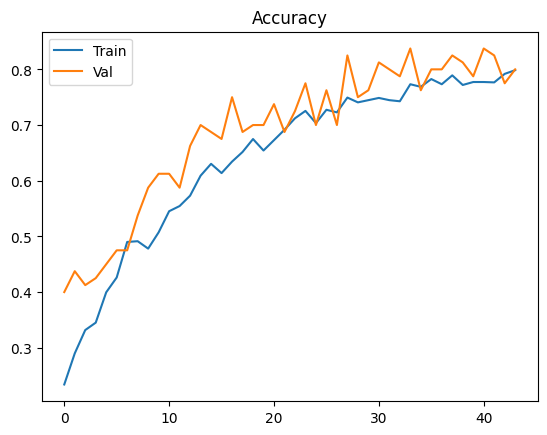

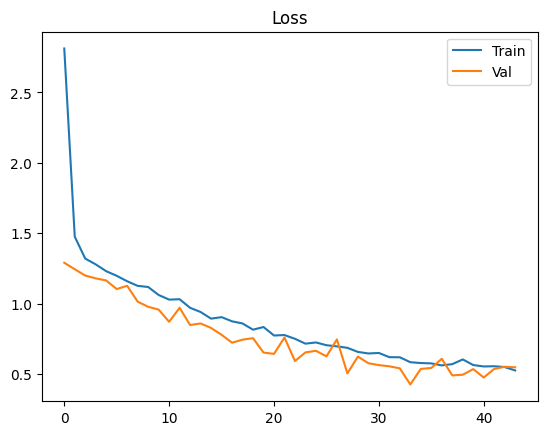

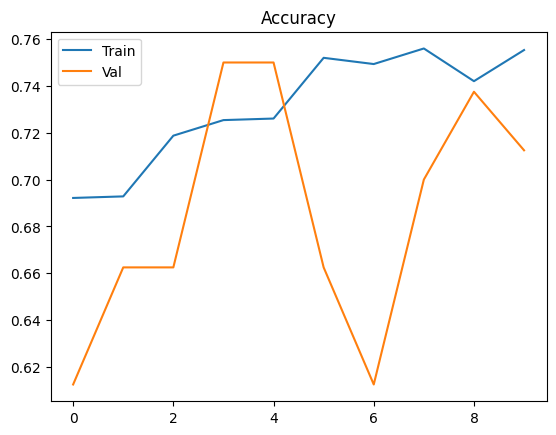

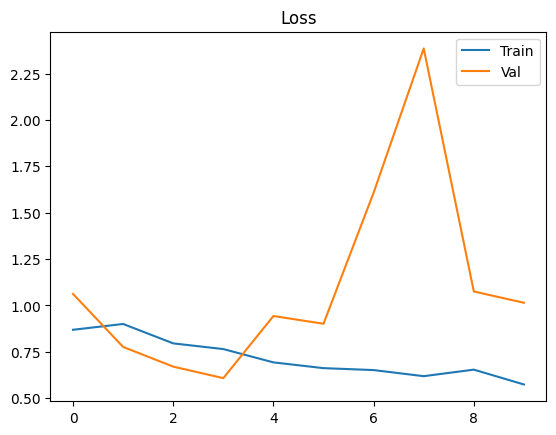

In [3]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.legend(['Train', 'Val'])
plt.title("Accuracy")
plt.show()

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['Train', 'Val'])
plt.title("Loss")
plt.show()

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(['Train', 'Val'])
plt.title("Accuracy")
plt.show()

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(['Train', 'Val'])
plt.title("Loss")
plt.show()

In [7]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/fusion_model_new_stage1.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

# Save the TFLite model directly to Google Drive
with open("/content/drive/MyDrive/fusion_model_new_stage1.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model successfully saved to /content/drive/MyDrive/fusion_model_new_stage1.tflite")


Saved artifact at '/tmp/tmphqbkcfwq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer_1'), TensorSpec(shape=(None, 4), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139634132022288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132023440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132023632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132024016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132012304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132025168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139634132023248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13963413202

In [8]:
# This cell is no longer needed as the TFLite model is saved directly to Google Drive in the previous step.
print("The TFLite model was saved directly to Google Drive in the previous cell. This cell is now redundant.")


The TFLite model was saved directly to Google Drive in the previous cell. This cell is now redundant.
